---
## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../docs/img', exist_ok=True)

print('Librerías cargadas')

Librerías cargadas


---
## 2. Carga del dataset

In [2]:
df = pd.read_csv('../data/raw/gym_churn_us.csv', sep=';')

COLS_AFECTADAS_POR_BUG = [
    'Avg_additional_charges_total',
    'Avg_class_frequency_total',
    'Avg_class_frequency_current_month'
]

# Bug de exportación: el separador decimal se confunde con el separador
# de miles de forma inconsistente fila a fila (ya detectado y documentado
# en el Notebook 01, celda 5). No existe una fórmula de reconstrucción
# fiable al 100%, así que se excluyen estas 3 columnas en vez de intentar
# repararlas. Ver business_case.md, apartado 2.1.
df = df.drop(columns=COLS_AFECTADAS_POR_BUG)

# Month_to_end_contract no tiene este bug, ya viene como número válido

print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')

Dataset cargado: 4000 filas, 11 columnas


In [3]:
VARS_NUMERICAS = [
    'Age', 'Contract_period',
    'Month_to_end_contract', 'Lifetime'
]

VARS_BINARIAS = [
    'gender', 'Near_Location', 'Partner',
    'Promo_friends', 'Phone', 'Group_visits'
]

TARGET = 'Churn'

print('Variables clasificadas')

Variables clasificadas


---
## 3. Limpieza

### 3.1 Confirmación de nulos y duplicados

In [4]:
nulos = df.isnull().sum()
print(nulos[nulos > 0] if (nulos > 0).any() else 'Sin valores nulos')

duplicados = df.duplicated().sum()
print(f'Registros duplicados: {duplicados}' if duplicados == 0 else f' {duplicados} duplicados detectados')

# Nota: estos duplicados aparecen como consecuencia de haber eliminado
# Avg_additional_charges_total y las dos columnas de frecuencia (bug de
# datos, ver celda anterior). NO son el mismo socio repetido dos veces:
# son socios distintos que comparten el mismo perfil en las 11 columnas
# restantes (mismo género, edad, tipo de contrato, etc.), algo esperable
# en un dataset de 4000 filas con variables de rango limitado. Con las
# 14 columnas originales había 0 duplicados. NO se eliminan estas filas:
# hacerlo borraría socios reales solo por compartir perfil demográfico.

Sin valores nulos
 859 duplicados detectados


### 3.2 Revisión de tipos de datos

In [5]:
print('Tipos de datos tras la carga:')
print(df.dtypes)
print(f'\nTodas las columnas numéricas son float o int: ',
      df[VARS_NUMERICAS].dtypes.apply(lambda t: 'int' in str(t) or 'float' in str(t)).all())

Tipos de datos tras la carga:
gender                     int64
Near_Location              int64
Partner                    int64
Promo_friends              int64
Phone                      int64
Contract_period            int64
Group_visits               int64
Age                        int64
Month_to_end_contract    float64
Lifetime                   int64
Churn                      int64
dtype: object

Todas las columnas numéricas son float o int:  True


### 3.3 Revisión de valores fuera de rango

Comprobamos que los valores de cada variable están dentro de los rangos 
definidos en el `data_dictionary.md`. Por ejemplo, la edad debe estar entre 16 y 80, 
y los valores binarios solo pueden ser 0 o 1.

In [6]:
print('=== RANGOS DE VARIABLES NUMÉRICAS ===')
for col in VARS_NUMERICAS:
    print(f'{col}: mín={df[col].min():.2f}  máx={df[col].max():.2f}')

print('\n=== VALORES ÚNICOS DE VARIABLES BINARIAS ===')
for col in VARS_BINARIAS:
    valores = sorted(df[col].unique())
    ok = valores == [0, 1]
    print(f'{col}: {valores} {"ok" if ok else "revisar"}')

print('\n=== CONTRACT_PERIOD ===')
print(f'Valores únicos: {sorted(df["Contract_period"].unique())} — esperado: [1, 6, 12]')

print('\n=== CHURN ===')
print(f'Valores únicos: {sorted(df[TARGET].unique())} — esperado: [0, 1]')

=== RANGOS DE VARIABLES NUMÉRICAS ===
Age: mín=18.00  máx=41.00
Contract_period: mín=1.00  máx=12.00
Month_to_end_contract: mín=1.00  máx=12.00
Lifetime: mín=0.00  máx=31.00

=== VALORES ÚNICOS DE VARIABLES BINARIAS ===
gender: [np.int64(0), np.int64(1)] ok
Near_Location: [np.int64(0), np.int64(1)] ok
Partner: [np.int64(0), np.int64(1)] ok
Promo_friends: [np.int64(0), np.int64(1)] ok
Phone: [np.int64(0), np.int64(1)] ok
Group_visits: [np.int64(0), np.int64(1)] ok

=== CONTRACT_PERIOD ===
Valores únicos: [np.int64(1), np.int64(6), np.int64(12)] — esperado: [1, 6, 12]

=== CHURN ===
Valores únicos: [np.int64(0), np.int64(1)] — esperado: [0, 1]


### 3.4 Comprobar que no hay datos con número negativos

In [7]:
cols_no_negativas = [
    'Age', 'Lifetime', 'Month_to_end_contract'
]

print('Registros con valores negativos en variables que no deberían tenerlos:')
for col in cols_no_negativas:
    negativos = (df[col] < 0).sum()
    estado = 'ok' if negativos == 0 else f' {negativos} registros'
    print(f'  {col}: {estado}')

Registros con valores negativos en variables que no deberían tenerlos:
  Age: ok
  Lifetime: ok
  Month_to_end_contract: ok


### Conclusión de la limpieza

El dataset está en perfectas condiciones para trabajar:
- Sin valores nulos
- Sin duplicados
- Tipos de datos correctos
- Todos los valores dentro de rango
- Sin negativos donde no corresponde

---
## Enriquecimiento

Campos nuevos creados a partir del dataset original:

- `genero_texto` — a partir de `gender`: etiqueta legible (Hombre / Mujer)
- `grupo_edad` — a partir de `Age`: tramos de edad (18-25 / 26-30 / 31-35 / 36-41)
- `tipo_contrato` — a partir de `Contract_period`: etiqueta del contrato (mensual / semestral / anual)
- `nivel_compromiso` — a partir de `Contract_period`: nivel de compromiso (bajo / medio / alto)
- `perfil_captacion` — a partir de `Promo_friends` + `Phone`: canal de captación y contactabilidad
- `segmento_lifetime` — a partir de `Lifetime`: etapa del socio (nuevo / intermedio / veterano)

**Nota:** se descartan los campos `variacion_frecuencia`, `tendencia_frecuencia` y `segmento_frecuencia` planteados inicialmente, por depender de columnas afectadas por el bug de exportación documentado al inicio de este notebook (ver business_case.md, apartado 2.1).

---
### Campo 1 — `genero_texto`


In [8]:
df['genero_texto'] = df['gender'].map({0: 'Mujer', 1: 'Hombre'})

# Verificamos el resultado
print('Distribución de genero_texto:')
print(df['genero_texto'].value_counts())

Distribución de genero_texto:
genero_texto
Hombre    2041
Mujer     1959
Name: count, dtype: int64


---
### Campo 2 — `grupo_edad`

In [9]:
df['grupo_edad'] = pd.cut(
    df['Age'],
    bins=[17, 25, 30, 35, 41],
    labels=['18-25', '26-30', '31-35', '36-41'],
    right=True
).astype(str)

print('Distribución de grupo_edad:')
print(df['grupo_edad'].value_counts().sort_index())

# Comprobamos que no hay socios sin grupo asignado
print(f'\nSocios sin grupo asignado: {df["grupo_edad"].isnull().sum()}')

Distribución de grupo_edad:
grupo_edad
18-25     536
26-30    2050
31-35    1323
36-41      91
Name: count, dtype: int64

Socios sin grupo asignado: 0


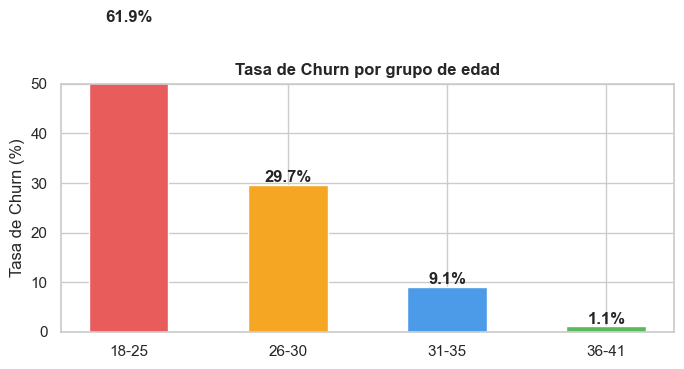

In [10]:
# Visualizamos la tasa de churn por grupo de edad
tasa_edad = df.groupby('grupo_edad', observed=True)[TARGET].mean() * 100

plt.figure(figsize=(7, 4))
bars = plt.bar(
    tasa_edad.index.astype(str),
    tasa_edad.values,
    color=['#E85C5C', '#F5A623', '#4C9BE8', '#5CB85C'],
    edgecolor='white',
    width=0.5
)
for bar, val in zip(bars, tasa_edad.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.title('Tasa de Churn por grupo de edad', fontweight='bold')
plt.ylabel('Tasa de Churn (%)')
plt.ylim(0, 50)
plt.tight_layout()
plt.savefig('../docs/img/07_churn_grupo_edad.png', bbox_inches='tight')
plt.show()

---
### Campos 3 y 4 — `tipo_contrato` y `nivel_compromiso`

In [11]:
df['tipo_contrato'] = df['Contract_period'].map({
    1:  'mensual',
    6:  'semestral',
    12: 'anual'
})

df['nivel_compromiso'] = df['Contract_period'].map({
    1:  'bajo',
    6:  'medio',
    12: 'alto'
})

print('tipo_contrato:')
print(df['tipo_contrato'].value_counts())
print('\nnivel_compromiso:')
print(df['nivel_compromiso'].value_counts())

tipo_contrato:
tipo_contrato
mensual      2207
anual         960
semestral     833
Name: count, dtype: int64

nivel_compromiso:
nivel_compromiso
bajo     2207
alto      960
medio     833
Name: count, dtype: int64


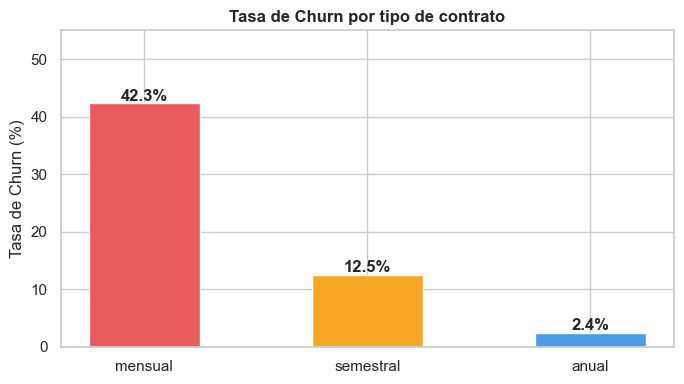

In [12]:
# Visualizamos la tasa de churn por tipo de contrato
orden = ['mensual', 'semestral', 'anual']
tasa_contrato = df.groupby('tipo_contrato')[TARGET].mean() * 100
tasa_contrato = tasa_contrato.reindex(orden)  # Ordenamos: mensual, semestral, anual

plt.figure(figsize=(7, 4))
bars = plt.bar(
    tasa_contrato.index,
    tasa_contrato.values,
    color=['#E85C5C', '#F5A623', '#4C9BE8'],
    edgecolor='white',
    width=0.5
)
for bar, val in zip(bars, tasa_contrato.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.title('Tasa de Churn por tipo de contrato', fontweight='bold')
plt.ylabel('Tasa de Churn (%)')
plt.ylim(0, 55)
plt.tight_layout()
plt.savefig('../docs/img/08_churn_tipo_contrato.png', bbox_inches='tight')
plt.show()

---
### Campo 5 — `perfil_captacion`

In [13]:
# Definimos las condiciones
condiciones = [
    (df['Promo_friends'] == 1) & (df['Phone'] == 1),
    (df['Promo_friends'] == 1) & (df['Phone'] == 0),
    (df['Promo_friends'] == 0) & (df['Phone'] == 1),
    (df['Promo_friends'] == 0) & (df['Phone'] == 0)
]

# La etiqueta que corresponde a cada condición (mismo orden)
etiquetas = [
    'referido_contactado',
    'referido_sin_contacto',
    'organico_contactado',
    'organico_sin_contacto'
]


df['perfil_captacion'] = np.select(
    condiciones,
    etiquetas,
    default='desconocido'   # ← añade este default string
).astype(str)

print('Distribución de perfil_captacion:')
print(df['perfil_captacion'].value_counts())

Distribución de perfil_captacion:
perfil_captacion
organico_contactado      2498
referido_contactado      1116
organico_sin_contacto     268
referido_sin_contacto     118
Name: count, dtype: int64


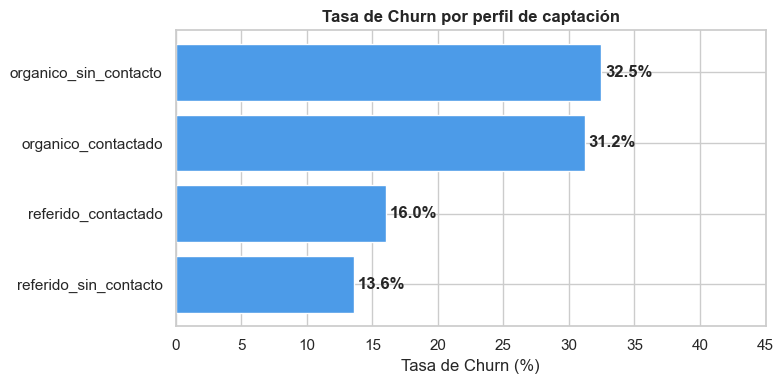

In [14]:
# Tasa de churn por perfil de captación
tasa_captacion = df.groupby('perfil_captacion')[TARGET].mean() * 100
tasa_captacion = tasa_captacion.sort_values(ascending=True)

plt.figure(figsize=(8, 4))
bars = plt.barh(
    tasa_captacion.index,
    tasa_captacion.values,
    color='#4C9BE8',
    edgecolor='white'
)
for bar, val in zip(bars, tasa_captacion.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold')
plt.title('Tasa de Churn por perfil de captación', fontweight='bold')
plt.xlabel('Tasa de Churn (%)')
plt.xlim(0, 45)
plt.tight_layout()
plt.savefig('../docs/img/09_churn_perfil_captacion.png', bbox_inches='tight')
plt.show()

---
### Campo 6 — `segmento_lifetime`

**Nota:** los campos `variacion_frecuencia`, `tendencia_frecuencia` y `segmento_frecuencia` que se planteaban originalmente en este punto se han descartado. Dependían de `Avg_class_frequency_total` y `Avg_class_frequency_current_month`, columnas excluidas por el bug de exportación detectado al inicio de este notebook (ver business_case.md, apartado 2.1).

Clasificamos a cada socio según su antigüedad. Los primeros meses son los más críticos 
para la retención (lo vimos en el Notebook 01: correlación de Lifetime con Churn = -0.44).

| Segmento | Rango de antigüedad | Interpretación |
|----------|---------------------|----------------|
| nuevo | 0 a 3 meses | Período más crítico, mayor riesgo |
| intermedio | 4 a 12 meses | Período de consolidación |
| veterano | Más de 12 meses | Socio fidelizado, menor riesgo |

In [15]:
df['segmento_lifetime'] = pd.cut(
    df['Lifetime'],
    bins=[-1, 3, 12, df['Lifetime'].max() + 1],
    labels=['nuevo', 'intermedio', 'veterano']
).astype(str)

print('Distribución de segmento_lifetime:')
print(df['segmento_lifetime'].value_counts().sort_index())

print('\nTasa de churn por segmento de lifetime:')
print((df.groupby('segmento_lifetime', observed=True)[TARGET].mean() * 100).round(1))

Distribución de segmento_lifetime:
segmento_lifetime
intermedio    1431
nuevo         2430
veterano       139
Name: count, dtype: int64

Tasa de churn por segmento de lifetime:
segmento_lifetime
intermedio     2.6
nuevo         42.1
veterano       0.0
Name: Churn, dtype: float64


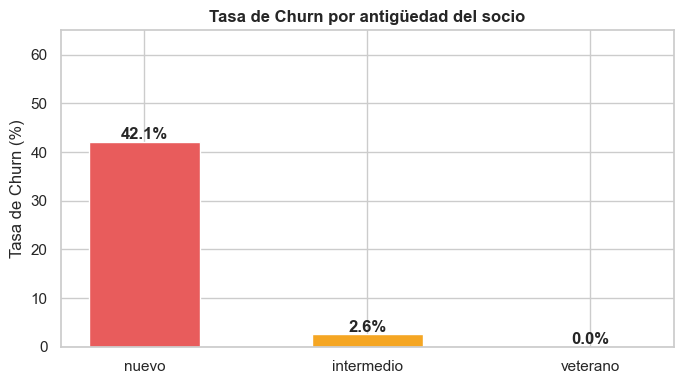

In [16]:
# Visualizamos la tasa de churn por segmento de lifetime
orden_lifetime = ['nuevo', 'intermedio', 'veterano']
tasa_lifetime = df.groupby('segmento_lifetime', observed=True)[TARGET].mean() * 100
tasa_lifetime = tasa_lifetime.reindex(orden_lifetime)

plt.figure(figsize=(7, 4))
bars = plt.bar(
    tasa_lifetime.index,
    tasa_lifetime.values,
    color=['#E85C5C', '#F5A623', '#4C9BE8'],
    edgecolor='white',
    width=0.5
)
for bar, val in zip(bars, tasa_lifetime.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.title('Tasa de Churn por antigüedad del socio', fontweight='bold')
plt.ylabel('Tasa de Churn (%)')
plt.ylim(0, 65)
plt.tight_layout()
plt.savefig('../docs/img/11_churn_segmento_lifetime.png', bbox_inches='tight')
plt.show()

---
## 3. Dataset enriquecido — Resumen final

In [17]:
# Columnas originales vs columnas nuevas
# (Avg_additional_charges_total, Avg_class_frequency_total y
# Avg_class_frequency_current_month ya no están: se eliminaron en la
# celda de carga por el bug de exportación documentado en business_case.md)
cols_originales = [
    'gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone',
    'Contract_period', 'Group_visits', 'Age',
    'Month_to_end_contract', 'Lifetime', 'Churn'
]

cols_nuevas = [
    'genero_texto', 'grupo_edad', 'tipo_contrato', 'nivel_compromiso',
    'perfil_captacion', 'segmento_lifetime'
]

print(f'Columnas originales: {len(cols_originales)}')
print(f'Columnas nuevas creadas: {len(cols_nuevas)}')
print(f'Total columnas en el dataset: {df.shape[1]}')

Columnas originales: 11
Columnas nuevas creadas: 6
Total columnas en el dataset: 17


In [18]:
# Visualizamos las primeras filas con las columnas nuevas
df[cols_nuevas].head()

,genero_texto,grupo_edad,tipo_contrato,nivel_compromiso,perfil_captacion,segmento_lifetime
0,Hombre,26-30,semestral,medio,referido_sin_contacto,nuevo
1,Mujer,31-35,anual,alto,organico_contactado,intermedio
2,Mujer,26-30,mensual,bajo,organico_contactado,nuevo
3,Mujer,31-35,anual,alto,referido_contactado,nuevo
4,Hombre,26-30,mensual,bajo,referido_contactado,nuevo


In [19]:
# Comprobamos que no hay ningún nulo en las columnas nuevas
print('Nulos en columnas nuevas:')
nulos_nuevos = df[cols_nuevas].isnull().sum()
print(nulos_nuevos)

Nulos en columnas nuevas:
genero_texto         0
grupo_edad           0
tipo_contrato        0
nivel_compromiso     0
perfil_captacion     0
segmento_lifetime    0
dtype: int64


---
## 4. Exportar el dataset enriquecido

In [20]:
ruta_salida = '../data/processed/gym_churn_enriquecido.csv'

df.to_csv(ruta_salida, index=False)

print(f'Dataset guardado en: {ruta_salida} ✅')
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')

Dataset guardado en: ../data/processed/gym_churn_enriquecido.csv ✅
Filas: 4000
Columnas: 17


In [21]:
# Verificamos que el archivo se guardó correctamente cargándolo de nuevo
df_check = pd.read_csv(ruta_salida)
print(f'Verificación — Dataset cargado desde disco:')
print(f'  Filas:    {df_check.shape[0]}')
print(f'  Columnas: {df_check.shape[1]}')

Verificación — Dataset cargado desde disco:
  Filas:    4000
  Columnas: 17


In [22]:
df_check = pd.read_csv('../data/processed/gym_churn_enriquecido.csv')

print(f'Filas: {df_check.shape[0]}')
print(f'Columnas: {df_check.shape[1]}')
print('\nColumnas disponibles:')
for col in df_check.columns:
    print(f'  - {col}')

Filas: 4000
Columnas: 17

Columnas disponibles:
  - gender
  - Near_Location
  - Partner
  - Promo_friends
  - Phone
  - Contract_period
  - Group_visits
  - Age
  - Month_to_end_contract
  - Lifetime
  - Churn
  - genero_texto
  - grupo_edad
  - tipo_contrato
  - nivel_compromiso
  - perfil_captacion
  - segmento_lifetime


## 5. Generación de los 5 CSV del modelo estrella

In [23]:
import os

os.makedirs('../data/processed/modelo_estrella', exist_ok=True)

In [24]:
# id_socio: el CSV no trae un identificador, así que lo generamos a partir de la posición de cada fila (1001, 1002, 1003...)
df['id_socio'] = df.index + 1001

In [25]:
# --- dim_contrato: catálogo fijo de 3 tipos de contrato ---
dim_contrato = pd.DataFrame({
    'id_contrato':      [1, 2, 3],
    'tipo_contrato':    ['mensual', 'semestral', 'anual'],
    'duracion_meses':   [1, 6, 12],
    'nivel_compromiso': ['bajo', 'medio', 'alto']
})
MAPA_ID_CONTRATO = {1: 1, 6: 2, 12: 3}
df['id_contrato'] = df['Contract_period'].map(MAPA_ID_CONTRATO)


In [26]:
# --- dim_captacion: catálogo fijo de 4 perfiles de captación ---
dim_captacion = pd.DataFrame({
    'id_captacion':        [1, 2, 3, 4],
    'viene_por_promo':     [0, 0, 1, 1],
    'telefono_registrado': [0, 1, 0, 1],
    'perfil_captacion':    ['organico_sin_contacto', 'organico_contactado',
                            'referido_sin_contacto', 'referido_contactado']
})
MAPA_ID_CAPTACION = {(0, 0): 1, (0, 1): 2, (1, 0): 3, (1, 1): 4}
df['id_captacion'] = df.apply(
    lambda fila: MAPA_ID_CAPTACION[(fila['Promo_friends'], fila['Phone'])], axis=1
)


In [30]:
dim_actividad = (
    df[['Group_visits']]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_actividad.columns = ['asiste_clases_grp']
dim_actividad.insert(0, 'id_actividad', dim_actividad.index + 1)

df = df.merge(
    dim_actividad,
    left_on='Group_visits',
    right_on='asiste_clases_grp',
    how='left'
)

In [31]:
# --- dim_socio ---
dim_socio = df[[
    'id_socio', 'genero_texto', 'Age', 'grupo_edad', 'Near_Location', 'Partner'
]].copy()
dim_socio.columns = ['id_socio', 'genero', 'edad', 'grupo_edad', 'vive_cerca', 'tiene_pareja_socia']

In [32]:
# --- fact_membresia ---
# Nota: ya no incluye gasto_adicional, frecuencia_total, frecuencia_mes
# ni variacion_frecuencia, por el mismo motivo explicado arriba.
fact_membresia = df[[
    'id_socio', 'id_contrato', 'id_captacion', 'id_actividad',
    'Lifetime', 'Month_to_end_contract', 'segmento_lifetime', 'Churn'
]].copy()
fact_membresia.columns = [
    'id_socio', 'id_contrato', 'id_captacion', 'id_actividad',
    'lifetime', 'meses_fin_contrato', 'segmento_lifetime', 'churn'
]

### 5.1 Exportamos los 5 CSV

In [33]:
RUTA_SALIDA = '../data/processed/modelo_estrella'

dim_socio.to_csv(f'{RUTA_SALIDA}/dim_socio.csv', index=False)
dim_contrato.to_csv(f'{RUTA_SALIDA}/dim_contrato.csv', index=False)
dim_captacion.to_csv(f'{RUTA_SALIDA}/dim_captacion.csv', index=False)
dim_actividad.to_csv(f'{RUTA_SALIDA}/dim_actividad.csv', index=False)
fact_membresia.to_csv(f'{RUTA_SALIDA}/fact_membresia.csv', index=False)

print('CSVs del modelo estrella generados en', RUTA_SALIDA)
print(f'  dim_socio:       {len(dim_socio)} filas')
print(f'  dim_contrato:    {len(dim_contrato)} filas')
print(f'  dim_captacion:   {len(dim_captacion)} filas')
print(f'  dim_actividad:   {len(dim_actividad)} filas')
print(f'  fact_membresia:  {len(fact_membresia)} filas')

CSVs del modelo estrella generados en ../data/processed/modelo_estrella
  dim_socio:       4000 filas
  dim_contrato:    3 filas
  dim_captacion:   4 filas
  dim_actividad:   2 filas
  fact_membresia:  4000 filas
